In [12]:
# @title 1. Install Dependencies
# Install system libraries required for VizDoom
!sudo apt-get update
!sudo apt-get install -y build-essential zlib1g-dev libsdl2-dev libjpeg-dev \
nasm tar libbz2-dev libgtk2.0-dev cmake git libfluidsynth-dev libgme-dev \
libopenal-dev timidity libwildmidi-dev libboost-all-dev

# Install Python libraries
!pip install stable-baselines3 shimmy>=1.3.0 gymnasium vizdoom opencv-python imageio

Hit:1 http://security.ubuntu.com/ubuntu jammy-security InRelease
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:4 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:5 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Fetched 3,917 B in 1s (3,770 B/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
build-essential is already the newest version (12.

In [ ]:
import vizdoom
import os

# Locate where the vizdoom library is installed
scenarios_path = os.path.join(os.path.dirname(vizdoom.__file__), "scenarios")

print(f"VizDoom Scenarios found at: {scenarios_path}")
print("Files available:", os.listdir(scenarios_path))

# Check specifically for Defend the Center
if "defend_the_center.wad" in os.listdir(scenarios_path):
    print("\n✅ SUCCESS: 'defend_the_center.wad' is present and ready to use!")
else:
    print("\n❌ ERROR: Game files missing.")

VizDoom Scenarios found at: /usr/local/lib/python3.12/dist-packages/vizdoom/scenarios
Files available: ['health_gathering.cfg', 'multi_duel.cfg', 'my_way_home.wad', 'oblige.cfg', 'rocket_basic.wad', 'cig.wad', 'simpler_basic.cfg', 'take_cover.wad', 'multi_duel.wad', 'defend_the_center.cfg', 'my_way_home.cfg', 'health_gathering.wad', 'README.md', 'basic.wad', 'predict_position.cfg', 'health_gathering_supreme.wad', 'cig_with_unknown.wad', 'learning.cfg', 'health_gathering_supreme.cfg', 'deadly_corridor.cfg', 'rocket_basic.cfg', 'deadly_corridor.wad', 'deathmatch.cfg', 'multi_deathmatch.wad', 'defend_the_line.cfg', 'cig.cfg', 'simpler_basic.wad', 'take_cover.cfg', 'predict_position.wad', 'deathmatch.wad', 'basic.cfg', 'multi.cfg', 'defend_the_line.wad', 'defend_the_center.wad']

✅ SUCCESS: 'defend_the_center.wad' is present and ready to use!


In [ ]:
# @title 2. Train and Evaluate Agent
import os
import time
import json
import cv2
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import imageio
import torch
import vizdoom
from vizdoom import DoomGame, Mode, ScreenFormat, ScreenResolution
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import VecTransposeImage
from IPython.display import Image, display

# --- COLAB SPECIFIC CONFIGURATION ---
os.environ["SDL_VIDEODRIVER"] = "dummy"

# Hyperparameters
CONFIG = {
    "timesteps": 1000000,
    "n_envs": 4,
    "frame_skip": 4,
    "n_steps": 512,
    "batch_size": 64,
    "learning_rate": 2.5e-4,
    "eval_episodes": 5,
    "seed": 42,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "log_dir": "/content/logs"
}

# --- 1. DEFINE CUSTOM ENVIRONMENT CLASS ---
# This bypasses all registry errors by wrapping VizDoom manually.
class VizDoomDefendCenter(gym.Env):
    def __init__(self, render_mode=None, frame_skip=4):
        super().__init__()
        self.frame_skip = frame_skip

        # 1. Locate Config File
        scenarios_dir = os.path.join(os.path.dirname(vizdoom.__file__), "scenarios")
        config_path = os.path.join(scenarios_dir, "defend_the_center.cfg")

        if not os.path.exists(config_path):
            raise FileNotFoundError(f"Could not find config at {config_path}")

        # 2. Initialize Game
        self.game = DoomGame()
        self.game.load_config(config_path)
        self.game.set_window_visible(False)
        self.game.set_mode(Mode.PLAYER)
        self.game.set_screen_format(ScreenFormat.RGB24)
        self.game.set_screen_resolution(ScreenResolution.RES_320X240)
        self.game.init()

        # 3. Define Spaces
        # Action space: 3 buttons (Turn Left, Turn Right, Attack)
        self.action_space = spaces.Discrete(3)

        # Observation space: The raw screen (H, W, 3)
        h, w = 240, 320
        self.observation_space = spaces.Dict({
            "screen": spaces.Box(0, 255, (h, w, 3), dtype=np.uint8)
        })

    def step(self, action):
        # Convert Discrete(3) to One-Hot for VizDoom
        # Buttons: [Turn Left, Turn Right, Attack]
        actions = [0.0] * 3
        actions[action] = 1.0

        reward = self.game.make_action(actions, self.frame_skip)
        done = self.game.is_episode_finished()

        if not done:
            state = self.game.get_state()
            screen = state.screen_buffer # Already RGB24
            info = {}
        else:
            screen = np.zeros((240, 320, 3), dtype=np.uint8)
            info = {
                "kills": self.game.get_game_variable(vizdoom.GameVariable.KILLCOUNT),
                "frags": self.game.get_game_variable(vizdoom.GameVariable.FRAGCOUNT)
            }
            # Important: Reset required by Gym interface if done, but VecEnv handles it.
            # However, standard Gym envs wait for reset().

        return {"screen": screen}, reward, done, False, info

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            self.game.set_seed(seed)
        self.game.new_episode()

        state = self.game.get_state()
        screen = state.screen_buffer
        return {"screen": screen}, {}

    def close(self):
        self.game.close()

# --- 2. Custom Wrapper for Resizing ---
class ObservationWrapper(gym.ObservationWrapper):
    def __init__(self, env, shape=(60, 80)):
        super().__init__(env)
        self.image_shape = shape
        self.image_shape_cv = shape[::-1]

        obs_shape = env.observation_space["screen"].shape
        new_shape = (shape[0], shape[1], obs_shape[-1])
        self.observation_space = gym.spaces.Box(0, 255, shape=new_shape, dtype=np.uint8)

    def observation(self, observation):
        screen = observation["screen"]
        resized = cv2.resize(screen, self.image_shape_cv, interpolation=cv2.INTER_AREA)
        return resized

# Factory to instantiate our Custom Class
def make_wrapped_env(frame_skip, monitor_dir=None, seed=0):
    def _init():
        env = VizDoomDefendCenter(frame_skip=frame_skip) # <--- Direct Instantiation
        env = ObservationWrapper(env)
        env = gym.wrappers.TransformReward(env, lambda r: r * 0.01)
        if monitor_dir:
            os.makedirs(monitor_dir, exist_ok=True)
            env = Monitor(env, os.path.join(monitor_dir, f"monitor_{int(time.time())}"))
        else:
            env = Monitor(env)
        return env
    return _init

# --- 3. Custom Callbacks ---
class DoomMetricsCallback(BaseCallback):
    def __init__(self, eval_env, eval_freq=5000, n_eval_episodes=5, verbose=1):
        super().__init__(verbose)
        self.eval_env = eval_env
        self.eval_freq = eval_freq
        self.n_eval_episodes = n_eval_episodes

    def _on_step(self):
        if self.n_calls % self.eval_freq == 0:
            kills, frags = [], []
            obs = self.eval_env.reset()
            for _ in range(self.n_eval_episodes):
                done = False
                while not done:
                    action, _ = self.model.predict(obs, deterministic=True)
                    obs, _, dones, infos = self.eval_env.step(action)
                    if dones[0]:
                        done = True
                        info = infos[0]
                        kills.append(info.get("kills", 0))
                        frags.append(info.get("frags", 0))

            if kills:
                self.logger.record("game/mean_kills", np.mean(kills))
                self.logger.record("game/mean_frags", np.mean(frags))
        return True

# --- 4. Main Training Flow ---

print(f"Training on: {CONFIG['device']}")

# Create Training Environment
# Note: We pass our factory function directly to make_vec_env
train_env = make_vec_env(
    make_wrapped_env(CONFIG['frame_skip'], CONFIG['log_dir']),
    n_envs=CONFIG['n_envs'],
    seed=CONFIG['seed']
)
train_env = VecTransposeImage(train_env)

# Create Evaluation Environment
eval_env = make_vec_env(
    make_wrapped_env(CONFIG['frame_skip'], None),
    n_envs=1,
    seed=CONFIG['seed'] + 1000
)
eval_env = VecTransposeImage(eval_env)

# Initialize Model
policy_kwargs = dict(features_extractor_kwargs=dict(features_dim=512)) if CONFIG['device'] == "cuda" else {}

model = PPO(
    "CnnPolicy",
    train_env,
    verbose=1,
    learning_rate=CONFIG['learning_rate'],
    n_steps=CONFIG['n_steps'],
    batch_size=CONFIG['batch_size'],
    device=CONFIG['device'],
    policy_kwargs=policy_kwargs,
    seed=CONFIG['seed'],
    tensorboard_log=os.path.join(CONFIG['log_dir'], "tensorboard")
)

# Train
print("Starting Training...")
model.learn(
    total_timesteps=CONFIG['timesteps'],
    callback=DoomMetricsCallback(eval_env, eval_freq=5000, n_eval_episodes=CONFIG['eval_episodes'])
)

# Save Model
model_path = os.path.join(CONFIG['log_dir'], "ppo_defend_center_colab.zip")
model.save(model_path)
print(f"Model saved to {model_path}")

# --- 5. Final Evaluation & GIF Generation ---
print("Generating Replay GIF...")
gif_env = make_wrapped_env(CONFIG['frame_skip'], None)()

frames = []
obs, _ = gif_env.reset()
done = False

while not done:
    # Our custom env returns RGB, no conversion needed usually
    if obs.shape[-1] == 1:
        frame = cv2.cvtColor(obs, cv2.COLOR_GRAY2RGB)
    else:
        frame = obs
    frames.append(frame)

    img = np.transpose(obs, (2, 0, 1))
    img = np.expand_dims(img, axis=0)

    action, _ = model.predict(img, deterministic=True)
    obs, _, terminated, truncated, _ = gif_env.step(action.item())
    done = terminated or truncated

gif_env.close()

gif_path = os.path.join(CONFIG['log_dir'], "colab_gameplay.gif")
imageio.mimsave(gif_path, frames, fps=30)

print(f"GIF saved to {gif_path}")
display(Image(filename=gif_path))

Streaming output truncated to the last 5000 lines.
|    time_elapsed         | 1192       |
|    total_timesteps      | 460800     |
| train/                  |            |
|    approx_kl            | 0.13273987 |
|    clip_fraction        | 0.271      |
|    clip_range           | 0.2        |
|    entropy_loss         | -0.4       |
|    explained_variance   | 0.919      |
|    learning_rate        | 0.00025    |
|    loss                 | -0.0738    |
|    n_updates            | 2240       |
|    policy_gradient_loss | -0.0419    |
|    value_loss           | 4.12e-05   |
----------------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 194        |
|    ep_rew_mean          | 0.119      |
| time/                   |            |
|    fps                  | 386        |
|    iterations           | 226        |
|    time_elapsed         | 1198       |
|    total_timesteps      | 462848     |
| trai

In [ ]:
%load_ext tensorboard
%tensorboard --logdir /content/logs/tensorboard

In [ ]:
# @title  High-Resolution Recording (640x480) record
import cv2
import numpy as np
import imageio
import os
import torch
import vizdoom
from vizdoom import DoomGame, Mode, ScreenFormat, ScreenResolution
from stable_baselines3 import PPO
from IPython.display import Image, display

# Configuration
MODEL_PATH = "/content/logs/ppo_defend_center_colab.zip"  # Path to your saved model
OUTPUT_FILE = "/content/logs/gameplay_hd.gif"
RESOLUTION = ScreenResolution.RES_640X480  # Much higher than training
FRAME_SKIP = 4

# --- 1. Define HD Environment Class ---
# This looks similar to the training class, but with higher resolution settings
class VizDoomHD:
    def __init__(self, model_path):
        # Locate Config
        scenarios_dir = os.path.join(os.path.dirname(vizdoom.__file__), "scenarios")
        config_path = os.path.join(scenarios_dir, "defend_the_center.cfg")

        self.game = DoomGame()
        self.game.load_config(config_path)
        self.game.set_window_visible(False)
        self.game.set_mode(Mode.PLAYER)
        self.game.set_screen_format(ScreenFormat.RGB24)

        # --- KEY CHANGE: Set High Resolution ---
        self.game.set_screen_resolution(RESOLUTION)
        self.game.init()

        # Load the trained agent
        print(f"Loading model from: {model_path}")
        self.model = PPO.load(model_path)

    def preprocess(self, screen_buffer):
        """
        Takes the HD screen (640x480) and shrinks it to what the agent expects (80x60).
        """
        # Resize to match the agent's training input (W=80, H=60)
        # Note: cv2.resize expects (Width, Height)
        resized = cv2.resize(screen_buffer, (80, 60), interpolation=cv2.INTER_AREA)

        # Re-order dimensions for PyTorch: (H, W, C) -> (C, H, W)
        obs = np.transpose(resized, (2, 0, 1))

        # Add batch dimension: (1, C, H, W)
        obs = np.expand_dims(obs, axis=0)
        return obs

    def record_episode(self, filename):
        frames = []
        self.game.new_episode()

        print("Recording HD Episode...")
        while not self.game.is_episode_finished():
            state = self.game.get_state()
            hd_screen = state.screen_buffer  # This is the 640x480 image

            # 1. Save HD frame for the video
            frames.append(hd_screen)

            # 2. Preprocess frame for the Agent
            agent_input = self.preprocess(hd_screen)

            # 3. Agent predicts action
            action, _ = self.model.predict(agent_input, deterministic=True)

            # 4. Convert Agent action (index) to VizDoom action (one-hot)
            # Buttons: [Turn Left, Turn Right, Attack]
            do_action = [0.0] * 3
            do_action[action.item()] = 1.0

            self.game.make_action(do_action, FRAME_SKIP)

        self.game.close()

        # Save to GIF
        print(f"Saving {len(frames)} HD frames to {filename}...")
        imageio.mimsave(filename, frames, fps=25)
        print("Done!")

# --- Run the Recorder ---
if os.path.exists(MODEL_PATH):
    recorder = VizDoomHD(MODEL_PATH)
    recorder.record_episode(OUTPUT_FILE)

    # Display
    display(Image(filename=OUTPUT_FILE))
else:
    print(f"Error: Model not found at {MODEL_PATH}. Did you finish training?")

Training on: cuda
Using cuda device
Starting Training...
Logging to /content/logs/tensorboard/PPO_6
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 82       |
|    ep_rew_mean     | -0.0316  |
| time/              |          |
|    fps             | 339      |
|    iterations      | 1        |
|    time_elapsed    | 6        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 85.5        |
|    ep_rew_mean          | -0.0288     |
| time/                   |             |
|    fps                  | 378         |
|    iterations           | 2           |
|    time_elapsed         | 10          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.010520784 |
|    clip_fraction        | 0.0767      |
|    clip_range           | 0.2         |
|    entropy_l

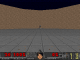

In [ ]:
# @title Train and Evaluate Agent (With Ammo Saving Mechanism)
import os
import time
import json
import cv2
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import imageio
import torch
import vizdoom
from vizdoom import DoomGame, Mode, ScreenFormat, ScreenResolution
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import VecTransposeImage
from IPython.display import Image, display

# --- COLAB SPECIFIC CONFIGURATION ---
os.environ["SDL_VIDEODRIVER"] = "dummy"

# Hyperparameters
CONFIG = {
    "timesteps": 100000,
    "n_envs": 4,
    "frame_skip": 4,
    "n_steps": 512,
    "batch_size": 64,
    "learning_rate": 2.5e-4,
    "eval_episodes": 5,
    "seed": 42,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "log_dir": "/content/logs"
}

# --- 1. DEFINE CUSTOM ENVIRONMENT CLASS ---
class VizDoomDefendCenter(gym.Env):
    def __init__(self, render_mode=None, frame_skip=4):
        super().__init__()
        self.frame_skip = frame_skip

        # 1. Locate Config File
        scenarios_dir = os.path.join(os.path.dirname(vizdoom.__file__), "scenarios")
        config_path = os.path.join(scenarios_dir, "defend_the_center.cfg")

        if not os.path.exists(config_path):
            raise FileNotFoundError(f"Could not find config at {config_path}")

        # 2. Initialize Game
        self.game = DoomGame()
        self.game.load_config(config_path)
        self.game.set_window_visible(False)
        self.game.set_mode(Mode.PLAYER)
        self.game.set_screen_format(ScreenFormat.RGB24)
        self.game.set_screen_resolution(ScreenResolution.RES_320X240)
        self.game.init()

        # 3. Define Spaces
        self.action_space = spaces.Discrete(3)
        h, w = 240, 320
        self.observation_space = spaces.Dict({
            "screen": spaces.Box(0, 255, (h, w, 3), dtype=np.uint8)
        })

    def step(self, action):
        # --- NEW: Capture stats BEFORE action ---
        # AMMO2 is the pistol ammo variable in Doom
        ammo_before = self.game.get_game_variable(vizdoom.GameVariable.AMMO2)
        kills_before = self.game.get_game_variable(vizdoom.GameVariable.KILLCOUNT)

        # Convert Discrete(3) to One-Hot
        actions = [0.0] * 3
        actions[action] = 1.0

        # Make action
        reward = self.game.make_action(actions, self.frame_skip)
        done = self.game.is_episode_finished()

        if not done:
            state = self.game.get_state()
            screen = state.screen_buffer
            info = {}

            # --- NEW: Custom Reward Shaping (Ammo Penalty) ---
            ammo_after = self.game.get_game_variable(vizdoom.GameVariable.AMMO2)
            kills_after = self.game.get_game_variable(vizdoom.GameVariable.KILLCOUNT)

            # Logic: If ammo decreased but kills didn't increase -> We missed!
            # Penalty: -0.5. (Note: The wrapper later scales this by 0.01)
            if (ammo_before > ammo_after) and (kills_before == kills_after):
                reward -= 0.25

        else:
            screen = np.zeros((240, 320, 3), dtype=np.uint8)
            info = {
                "kills": self.game.get_game_variable(vizdoom.GameVariable.KILLCOUNT),
                "frags": self.game.get_game_variable(vizdoom.GameVariable.FRAGCOUNT)
            }

        return {"screen": screen}, reward, done, False, info

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            self.game.set_seed(seed)
        self.game.new_episode()

        state = self.game.get_state()
        screen = state.screen_buffer
        return {"screen": screen}, {}

    def close(self):
        self.game.close()

# --- 2. Custom Wrapper for Resizing ---
class ObservationWrapper(gym.ObservationWrapper):
    def __init__(self, env, shape=(60, 80)):
        super().__init__(env)
        self.image_shape = shape
        self.image_shape_cv = shape[::-1]

        obs_shape = env.observation_space["screen"].shape
        new_shape = (shape[0], shape[1], obs_shape[-1])
        self.observation_space = gym.spaces.Box(0, 255, shape=new_shape, dtype=np.uint8)

    def observation(self, observation):
        screen = observation["screen"]
        resized = cv2.resize(screen, self.image_shape_cv, interpolation=cv2.INTER_AREA)
        return resized

# Factory to instantiate our Custom Class
def make_wrapped_env(frame_skip, monitor_dir=None, seed=0):
    def _init():
        env = VizDoomDefendCenter(frame_skip=frame_skip)
        env = ObservationWrapper(env)
        # Keeps your original scaling (x 0.01)
        env = gym.wrappers.TransformReward(env, lambda r: r * 0.01)
        if monitor_dir:
            os.makedirs(monitor_dir, exist_ok=True)
            env = Monitor(env, os.path.join(monitor_dir, f"monitor_{int(time.time())}"))
        else:
            env = Monitor(env)
        return env
    return _init

# --- 3. Custom Callbacks ---
class DoomMetricsCallback(BaseCallback):
    def __init__(self, eval_env, eval_freq=5000, n_eval_episodes=5, verbose=1):
        super().__init__(verbose)
        self.eval_env = eval_env
        self.eval_freq = eval_freq
        self.n_eval_episodes = n_eval_episodes

    def _on_step(self):
        if self.n_calls % self.eval_freq == 0:
            kills, frags = [], []
            obs = self.eval_env.reset()
            for _ in range(self.n_eval_episodes):
                done = False
                while not done:
                    action, _ = self.model.predict(obs, deterministic=True)
                    obs, _, dones, infos = self.eval_env.step(action)
                    if dones[0]:
                        done = True
                        info = infos[0]
                        kills.append(info.get("kills", 0))
                        frags.append(info.get("frags", 0))

            if kills:
                self.logger.record("game/mean_kills", np.mean(kills))
                self.logger.record("game/mean_frags", np.mean(frags))
        return True

# --- 4. Main Training Flow ---

print(f"Training on: {CONFIG['device']}")

# Create Training Environment
train_env = make_vec_env(
    make_wrapped_env(CONFIG['frame_skip'], CONFIG['log_dir']),
    n_envs=CONFIG['n_envs'],
    seed=CONFIG['seed']
)
train_env = VecTransposeImage(train_env)

# Create Evaluation Environment
eval_env = make_vec_env(
    make_wrapped_env(CONFIG['frame_skip'], None),
    n_envs=1,
    seed=CONFIG['seed'] + 1000
)
eval_env = VecTransposeImage(eval_env)

# Initialize Model
policy_kwargs = dict(features_extractor_kwargs=dict(features_dim=512)) if CONFIG['device'] == "cuda" else {}

model = PPO(
    "CnnPolicy",
    train_env,
    verbose=1,
    learning_rate=CONFIG['learning_rate'],
    n_steps=CONFIG['n_steps'],
    batch_size=CONFIG['batch_size'],
    device=CONFIG['device'],
    policy_kwargs=policy_kwargs,
    seed=CONFIG['seed'],
    tensorboard_log=os.path.join(CONFIG['log_dir'], "tensorboard")
)

# Train
print("Starting Training...")
model.learn(
    total_timesteps=CONFIG['timesteps'],
    callback=DoomMetricsCallback(eval_env, eval_freq=5000, n_eval_episodes=CONFIG['eval_episodes'])
)

# Save Model
model_path = os.path.join(CONFIG['log_dir'], "ppo_defend_center_colab.zip")
model.save(model_path)
print(f"Model saved to {model_path}")

# --- 5. Final Evaluation & GIF Generation ---
print("Generating Replay GIF...")
gif_env = make_wrapped_env(CONFIG['frame_skip'], None)()

frames = []
obs, _ = gif_env.reset()
done = False

while not done:
    if obs.shape[-1] == 1:
        frame = cv2.cvtColor(obs, cv2.COLOR_GRAY2RGB)
    else:
        frame = obs
    frames.append(frame)

    img = np.transpose(obs, (2, 0, 1))
    img = np.expand_dims(img, axis=0)

    action, _ = model.predict(img, deterministic=True)
    obs, _, terminated, truncated, _ = gif_env.step(action.item())
    done = terminated or truncated

gif_env.close()

gif_path = os.path.join(CONFIG['log_dir'], "colab_gameplay.gif")
imageio.mimsave(gif_path, frames, fps=30)

print(f"GIF saved to {gif_path}")
display(Image(filename=gif_path))

Running Side-by-Side simulation...
Rendering 101 comparison frames...
 Processed 0/101
 Processed 20/101
 Processed 40/101
 Processed 60/101
 Processed 80/101
 Processed 100/101

✅ SIDE-BY-SIDE GIF SAVED: /content/logs/eyes_vs_brain_slowmo.gif


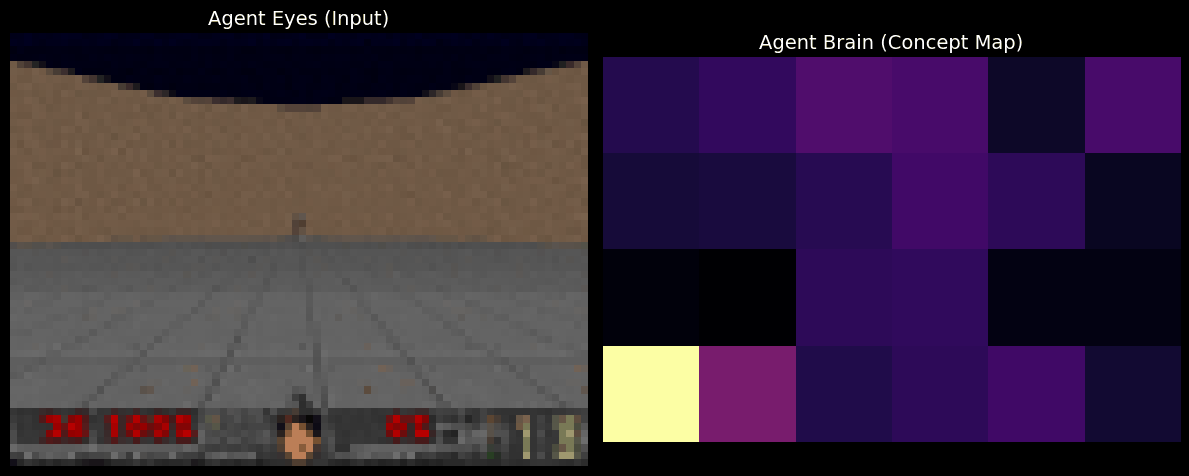

In [ ]:
# @title 9. Side-by-Side Comparison: "Eyes vs. Brain"
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import numpy as np
from PIL import Image
import io
import os
from stable_baselines3 import PPO

# --- CONFIG ---
MODEL_PATH = "/content/ppo_defend_center_colab.zip"
OUTPUT_PATH = "/content/logs/eyes_vs_brain_slowmo.gif"
FPS = 5  # Slow motion (5 frames per second)

# Load Model
if os.path.exists(MODEL_PATH):
    model = PPO.load(MODEL_PATH)
else:
    raise FileNotFoundError(f"Model not found at {MODEL_PATH}")

def get_last_layer_activity(model, obs):
    """
    Get the activity of the final Convolutional Layer.
    Returns the MAX activation across all filters (The 'Hotspot' map).
    """
    cnn = model.policy.features_extractor.cnn

    # Prepare Input
    if len(obs.shape) == 3 and obs.shape[-1] == 3:
        obs_transposed = np.transpose(obs, (2, 0, 1))
    else:
        obs_transposed = obs

    obs_tensor = torch.as_tensor(obs_transposed).float().unsqueeze(0).to(model.device)

    # Loop through layers to get the last Conv2d output
    last_output = None
    for layer in cnn:
        obs_tensor = layer(obs_tensor)
        if isinstance(layer, nn.Conv2d):
            last_output = obs_tensor.clone()

    if last_output is not None:
        # Shape is (1, 64, H, W)
        # We take the MAX across the 64 filters to see "Where is the network most excited?"
        features = last_output.squeeze(0).cpu().detach().numpy()
        max_activation = np.max(features, axis=0)
        return max_activation
    return None

def create_side_by_side_frame(game_frame, brain_map):
    """
    Stitches the Game Frame and the Brain Map into one image.
    """
    # Create a figure with 2 columns
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), facecolor='black')

    # --- LEFT: THE EYES (Game Screen) ---
    axes[0].imshow(game_frame)
    axes[0].set_title("Agent Eyes (Input)", color='white', fontsize=14)
    axes[0].axis('off')

    # --- RIGHT: THE BRAIN (Last Layer) ---
    # We use 'nearest' interpolation to show the raw, blocky grid of the neural net
    im = axes[1].imshow(brain_map, cmap='inferno', interpolation='nearest')
    axes[1].set_title("Agent Brain (Concept Map)", color='white', fontsize=14)
    axes[1].axis('off')

    # Add a subtle grid to the brain map to emphasize it's a grid of neurons
    h, w = brain_map.shape
    axes[1].set_xticks(np.arange(-.5, w, 1), minor=True)
    axes[1].set_yticks(np.arange(-.5, h, 1), minor=True)
    axes[1].grid(which='minor', color='black', linestyle='-', linewidth=1, alpha=0.3)

    plt.tight_layout()

    # Convert to PIL
    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight', facecolor='black')
    buf.seek(0)
    img = Image.open(buf).convert('RGB')
    plt.close(fig)
    return img

# --- EXECUTION ---

print("Running Side-by-Side simulation...")
sample_env = make_wrapped_env(CONFIG['frame_skip'], None)()
obs, _ = sample_env.reset()
obs_list = [obs]

# Record 100 steps (approx 3-4 seconds of gameplay)
for step in range(100):
    action, _ = model.predict(obs, deterministic=False)
    obs, reward, terminated, truncated, _ = sample_env.step(action)
    obs_list.append(obs.copy())
    if terminated or truncated:
        break
sample_env.close()

# Generate Frames
print(f"Rendering {len(obs_list)} comparison frames...")
gif_frames = []

for i, obs in enumerate(obs_list):
    # Get the "Brain" map
    brain_activity = get_last_layer_activity(model, obs)

    if brain_activity is not None:
        # Create the combined image
        img = create_side_by_side_frame(obs, brain_activity)
        gif_frames.append(img)

    if i % 20 == 0: print(f" Processed {i}/{len(obs_list)}")

# Save GIF
if gif_frames:
    duration_per_frame = int(1000 / FPS) # Convert FPS to Milliseconds

    gif_frames[0].save(
        OUTPUT_PATH,
        save_all=True,
        append_images=gif_frames[1:],
        duration=duration_per_frame,
        loop=0
    )
    print(f"\n✅ SIDE-BY-SIDE GIF SAVED: {OUTPUT_PATH}")
    from IPython.display import Image as IPImage, display
    display(IPImage(filename=OUTPUT_PATH))

In [ ]:

import os
import time
import cv2
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import imageio
import torch
import vizdoom
from vizdoom import DoomGame, Mode, ScreenFormat, ScreenResolution, GameVariable
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.monitor import Monitor


# --- COLAB SPECIFIC CONFIGURATION ---
os.environ["SDL_VIDEODRIVER"] = "dummy"

# Hyperparameters
CONFIG = {
    "timesteps": 600000,       # Reduced for testing (increase to 1.5M for paper)
    "n_envs": 4,
    "frame_skip": 4,
    "n_steps": 512,
    "batch_size": 64,
    "learning_rate": 2.0e-4,
    "eval_episodes": 5,
    "seed": 42,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "log_dir": "/content/logs_multiobj"
}

# --- 1. DEFINE BASE ENVIRONMENT ---
class VizDoomDefendCenter(gym.Env):
    def __init__(self, render_mode=None, frame_skip=4):
        super().__init__()
        self.frame_skip = frame_skip

        # 1. Locate Config
        scenarios_dir = os.path.join(os.path.dirname(vizdoom.__file__), "scenarios")
        config_path = os.path.join(scenarios_dir, "defend_the_center.cfg")
        if not os.path.exists(config_path):
            raise FileNotFoundError(f"Could not find config at {config_path}")

        # 2. Initialize Game
        self.game = DoomGame()
        self.game.load_config(config_path)
        self.game.set_window_visible(False)
        self.game.set_mode(Mode.PLAYER)
        self.game.set_screen_format(ScreenFormat.RGB24)
        self.game.set_screen_resolution(ScreenResolution.RES_320X240)

        # Enable variables we need for Multi-Objective Rewards
        self.game.set_available_game_variables([
            GameVariable.KILLCOUNT,
            GameVariable.AMMO2,    # Pistol Ammo
            GameVariable.HEALTH
        ])

        self.game.init()

        # 3. Define Spaces
        self.action_space = spaces.Discrete(3)
        h, w = 240, 320
        self.observation_space = spaces.Dict({
            "screen": spaces.Box(0, 255, (h, w, 3), dtype=np.uint8)
        })

        # Track previous state for delta calculation
        self.prev_vars = {"kills": 0, "ammo": 26, "health": 100}

    def step(self, action):
        actions = [0.0] * 3
        actions[action] = 1.0

        # We ignore the built-in reward; we calculate our own
        self.game.make_action(actions, self.frame_skip)
        done = self.game.is_episode_finished()

        if not done:
            state = self.game.get_state()
            screen = state.screen_buffer

            # Fetch current variables
            curr_kills = self.game.get_game_variable(GameVariable.KILLCOUNT)
            curr_ammo = self.game.get_game_variable(GameVariable.AMMO2)
            curr_health = self.game.get_game_variable(GameVariable.HEALTH)

            # Calculate Deltas (Raw Signals)
            r_kill = (curr_kills - self.prev_vars["kills"])        # +1 per kill
            r_ammo = (curr_ammo - self.prev_vars["ammo"])          # Negative if shot fired
            r_pain = (curr_health - self.prev_vars["health"])      # Negative if damaged

            # Update history
            self.prev_vars = {"kills": curr_kills, "ammo": curr_ammo, "health": curr_health}

            # Pack raw info for the Wrapper to use
            info = {
                "r_kill": r_kill,
                "r_ammo": r_ammo,
                "r_pain": r_pain,
                "kills": curr_kills
            }
        else:
            screen = np.zeros((240, 320, 3), dtype=np.uint8)
            info = {
                "r_kill": 0, "r_ammo": 0, "r_pain": 0,
                "kills": self.prev_vars["kills"] # Return final killcount
            }

        return {"screen": screen}, 0, done, False, info

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            self.game.set_seed(seed)
        self.game.new_episode()

        self.prev_vars = {"kills": 0, "ammo": 26, "health": 100}

        state = self.game.get_state()
        screen = state.screen_buffer
        return {"screen": screen}, {}

    def close(self):
        self.game.close()

# --- 2. MULTI-OBJECTIVE WRAPPER (THE CORE INNOVATION) ---
class ConditionedDoomWrapper(gym.ObservationWrapper):
    def __init__(self, env, shape=(60, 80), fixed_weights=None):
        super().__init__(env)
        self.image_shape = shape
        self.image_shape_cv = shape[::-1]
        self.fixed_weights = fixed_weights # If set, agent is locked to one personality

        # Update Observation Space: Image + Weight Vector (3,)
        # We put image in (C, H, W) for PyTorch efficiency
        new_shape = (3, shape[0], shape[1])
        self.observation_space = spaces.Dict({
            "image": spaces.Box(0, 255, shape=new_shape, dtype=np.uint8),
            "weights": spaces.Box(0, 1, shape=(3,), dtype=np.float32)
        })

        # Default Weights
        self.current_weights = np.array([0.33, 0.33, 0.33], dtype=np.float32)

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)

        if self.fixed_weights is not None:
            # For Evaluation: Force specific profile
            self.current_weights = np.array(self.fixed_weights, dtype=np.float32)
        else:
            # For Training: Sample from Dirichlet (random trade-offs)
            # Alpha=1 gives uniform spread over the simplex
            self.current_weights = np.random.dirichlet((1, 1, 1)).astype(np.float32)

        return self.observation(obs), info

    def observation(self, observation):
        screen = observation["screen"]
        resized = cv2.resize(screen, self.image_shape_cv, interpolation=cv2.INTER_AREA)
        # Transpose to Channel-First (C, H, W)
        resized = np.transpose(resized, (2, 0, 1))

        return {
            "image": resized,
            "weights": self.current_weights
        }

    def step(self, action):
        # 1. Get Environment Step
        obs, _, terminated, truncated, info = self.env.step(action)

        # 2. Extract Raw Signals
        r_kill = info.get("r_kill", 0)
        r_ammo = info.get("r_ammo", 0)
        r_pain = info.get("r_pain", 0)

        # 3. Normalize/Scale Signals (Crucial for balancing)
        # Kill: +1.0 is fine.
        # Ammo: Raw is -1 (clip count) or usually just small.
        #       Let's say shooting costs -0.05 reward points.
        # Pain: Raw is -Damage. Let's say -10 HP = -0.5 reward.

        proc_kill = r_kill * 1.0
        proc_ammo = r_ammo * 0.05  # If r_ammo is -1 (shot), result is -0.05
        proc_pain = r_pain * 0.01  # If r_pain is -10 (dmg), result is -0.1

        # 4. Calculate Scalarized Reward
        # R = w_k*K + w_a*A + w_p*P
        w_k, w_a, w_p = self.current_weights

        scalar_reward = (w_k * proc_kill) + (w_a * proc_ammo) + (w_p * proc_pain)

        # Add a tiny living reward to encourage existing, but weight it by pain preference
        # (If I care about pain, I care about living)
        scalar_reward += 0.001

        return self.observation(obs), scalar_reward, terminated, truncated, info

# Factory
def make_conditioned_env(frame_skip, monitor_dir=None, seed=0, fixed_weights=None):
    def _init():
        env = VizDoomDefendCenter(frame_skip=frame_skip)
        env = ConditionedDoomWrapper(env, fixed_weights=fixed_weights)
        if monitor_dir:
            os.makedirs(monitor_dir, exist_ok=True)
            env = Monitor(env, os.path.join(monitor_dir, f"monitor_{int(time.time())}"))
        else:
            env = Monitor(env)
        return env
    return _init


# --- 3. TRAINING FLOW ---

print(f"Training Multi-Objective Agent on: {CONFIG['device']}")

# Train with Randomized Weights
train_env = make_vec_env(
    make_conditioned_env(CONFIG['frame_skip'], CONFIG['log_dir']),
    n_envs=CONFIG['n_envs'],
    seed=CONFIG['seed']
)

# Eval with Balanced Weights
eval_env = make_vec_env(
    make_conditioned_env(CONFIG['frame_skip'], None, fixed_weights=[0.34, 0.33, 0.33]),
    n_envs=1,
    seed=CONFIG['seed'] + 1000
)

# Initialize Model with Corrected kwargs
# REMOVED: features_extractor_kwargs=dict(features_dim=512)
# The CombinedExtractor calculates dimensions automatically.
policy_kwargs = dict(
    net_arch=dict(pi=[128, 128], vf=[128, 128])
)

model = PPO(
    "MultiInputPolicy",
    train_env,
    verbose=1,
    learning_rate=CONFIG['learning_rate'],
    n_steps=CONFIG['n_steps'],
    batch_size=CONFIG['batch_size'],
    device=CONFIG['device'],
    policy_kwargs=policy_kwargs,   # <--- Fixed here
    seed=CONFIG['seed'],
    tensorboard_log=os.path.join(CONFIG['log_dir'], "tensorboard_morl")
)

# Train
print("Starting MORL Training...")
model.learn(
    total_timesteps=CONFIG['timesteps'],
    callback=DoomMetricsCallback(eval_env, eval_freq=10000, n_eval_episodes=5)
)

model.save(os.path.join(CONFIG['log_dir'], "ppo_morl_conditioned.zip"))

Streaming output truncated to the last 5000 lines.
|    loss                 | -0.00696  |
|    n_updates            | 560       |
|    policy_gradient_loss | -0.0283   |
|    value_loss           | 0.0343    |
---------------------------------------
---------------------------------------
| rollout/                |           |
|    ep_len_mean          | 220       |
|    ep_rew_mean          | 4.27      |
| time/                   |           |
|    fps                  | 354       |
|    iterations           | 58        |
|    time_elapsed         | 335       |
|    total_timesteps      | 118784    |
| train/                  |           |
|    approx_kl            | 0.1125367 |
|    clip_fraction        | 0.3       |
|    clip_range           | 0.2       |
|    entropy_loss         | -0.431    |
|    explained_variance   | 0.959     |
|    learning_rate        | 0.0002    |
|    loss                 | -0.0598   |
|    n_updates            | 570       |
|    policy_gradient_loss | -